In [9]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

df_tv = pd.read_csv("train_ind_prc.csv")
df_test = pd.read_csv("test_ind_prc.csv")
df_tv = df_tv.drop(['num__installment'], axis=1)
df_test = df_test.drop(['num__installment'], axis=1)


df_tv_exiti = df_tv.drop(['rf_rate','REAL_IRR'], axis=1)
df_test_exiti = df_test.drop(['rf_rate','REAL_IRR'], axis=1)

In [10]:
def cal_IRR(row):
    if row['pred_y'] == 1:
        return row['rf_rate']
    elif row['pred_y'] == 0:
        return row['REAL_IRR']
    else:
        return None

def cal_SR(df):
    excess_returns = df['IRR'] - df['rf_rate']
    if excess_returns.std() == 0:
        return 0
    return excess_returns.mean() / excess_returns.std()

In [11]:
# 최적 하이퍼파라미터를 찾기 위해 샘플 스플릿 with seed 0

X_tv = df_tv.drop('y', axis=1)
X_test = df_test.drop('y', axis=1)
y_tv = df_tv['y']
y_test = df_test['y']

X_train_R, X_val_R, y_train, y_val = train_test_split(X_tv, y_tv, stratify=y_tv, test_size=0.1, random_state=0)

X_train = X_train_R.drop(["rf_rate", "REAL_IRR"], axis=1) 
X_val = X_val_R.drop(["rf_rate", "REAL_IRR"], axis=1)

import optuna

def objective(trial):
    param = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'is_unbalance': True,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'verbose': -1
     }
            
    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)
    model = lgb.train(param, lgb_train, num_boost_round=200, valid_sets=[lgb_val])
    pred_y_proba = model.predict(X_val)
    pred_y = (pred_y_proba > 0.5).astype(int)
    X_val_R['pred_y'] = pred_y
    X_val_R['IRR'] = X_val_R.apply(cal_IRR, axis=1)
    best_sr = cal_SR(X_val_R)
    
    return best_sr

def optuna_lgbm(n_trials):
    best_results = []
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial), n_trials=n_trials)
    best_sr = study.best_value
    best_params = study.best_params
    best_results.append({
            'Sharpe': best_sr, 
            'params': best_params, 
        })
    return best_results

best_results = optuna_lgbm(n_trials=20)


[I 2025-08-19 20:40:34,834] A new study created in memory with name: no-name-c859ad8e-2bdf-4444-bfa4-c161b02ad9f7
[I 2025-08-19 20:40:41,277] Trial 0 finished with value: 0.18934054819207005 and parameters: {'learning_rate': 0.06727154470956659, 'num_leaves': 23, 'max_depth': 7, 'min_data_in_leaf': 70, 'feature_fraction': 0.8166512365637739, 'bagging_fraction': 0.8447884998173518, 'bagging_freq': 1}. Best is trial 0 with value: 0.18934054819207005.
[I 2025-08-19 20:40:41,277] Trial 0 finished with value: 0.18934054819207005 and parameters: {'learning_rate': 0.06727154470956659, 'num_leaves': 23, 'max_depth': 7, 'min_data_in_leaf': 70, 'feature_fraction': 0.8166512365637739, 'bagging_fraction': 0.8447884998173518, 'bagging_freq': 1}. Best is trial 0 with value: 0.18934054819207005.
[I 2025-08-19 20:40:46,664] Trial 1 finished with value: 0.16689898627461422 and parameters: {'learning_rate': 0.014889194229887699, 'num_leaves': 53, 'max_depth': 5, 'min_data_in_leaf': 78, 'feature_fraction

In [13]:
best_results[0]['params']

{'learning_rate': 0.09486920554385464,
 'num_leaves': 85,
 'max_depth': 11,
 'min_data_in_leaf': 50,
 'feature_fraction': 0.7666517476697042,
 'bagging_fraction': 0.7823864507085816,
 'bagging_freq': 5}

In [14]:
# 최적 하이퍼파라미터 저장
optimal_params = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'is_unbalance': True,
        'learning_rate': 0.09486920554385464,
        'num_leaves': 85,
        'max_depth': 11,
        'min_data_in_leaf': 50,
        'feature_fraction': 0.7666517476697042,
        'bagging_fraction': 0.7823864507085816,
        'bagging_freq': 5,
        'verbose': -1
     }

Running bootstrap threshold optimization with fixed hyperparameters...

=== Bootstrap 1/30 ===
Bootstrap 1: Best Sharpe=0.2009, Threshold=0.423

=== Bootstrap 2/30 ===
Bootstrap 1: Best Sharpe=0.2009, Threshold=0.423

=== Bootstrap 2/30 ===
Bootstrap 2: Best Sharpe=0.1992, Threshold=0.423

=== Bootstrap 3/30 ===
Bootstrap 2: Best Sharpe=0.1992, Threshold=0.423

=== Bootstrap 3/30 ===
Bootstrap 3: Best Sharpe=0.1984, Threshold=0.423

=== Bootstrap 4/30 ===
Bootstrap 3: Best Sharpe=0.1984, Threshold=0.423

=== Bootstrap 4/30 ===
Bootstrap 4: Best Sharpe=0.1990, Threshold=0.423

=== Bootstrap 5/30 ===
Bootstrap 4: Best Sharpe=0.1990, Threshold=0.423

=== Bootstrap 5/30 ===
Bootstrap 5: Best Sharpe=0.1996, Threshold=0.423

=== Bootstrap 6/30 ===
Bootstrap 5: Best Sharpe=0.1996, Threshold=0.423

=== Bootstrap 6/30 ===
Bootstrap 6: Best Sharpe=0.2009, Threshold=0.423

=== Bootstrap 7/30 ===
Bootstrap 6: Best Sharpe=0.2009, Threshold=0.423

=== Bootstrap 7/30 ===
Bootstrap 7: Best Sharpe=0.20

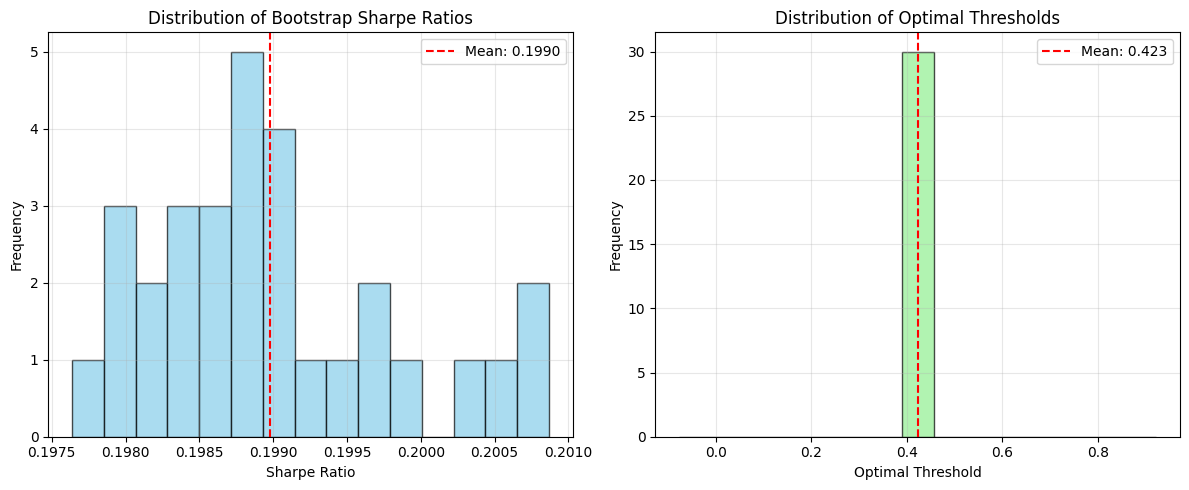

In [17]:
from sklearn.utils import resample

def bootstrap_threshold_optimization(df_tv, n_bootstrap, n_thresholds):
    best_results = []

    for i in range(n_bootstrap):
        print(f"\n=== Bootstrap {i+1}/{n_bootstrap} ===")
        
        # Bootstrap sampling
        df_boot = resample(df_tv, replace=True, n_samples=len(df_tv), random_state=i)
        X_tv = df_boot.drop('y', axis=1)
        y_tv = df_boot['y']
        X_test_R = df_test.drop('y', axis=1)

        X_train_R, X_val_R, y_train, y_val = train_test_split(X_tv, y_tv, stratify=y_tv, test_size=0.1, random_state=0)

        X_train = X_train_R.drop(["rf_rate", "REAL_IRR"], axis=1) 
        X_val = X_val_R.drop(["rf_rate", "REAL_IRR"], axis=1)
        X_test = X_test_R.drop(["rf_rate", "REAL_IRR"], axis=1)

        # Train model with fixed optimal parameters
        lgb_train = lgb.Dataset(X_train, y_train)
        lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)
        model = lgb.train(optimal_params, lgb_train, num_boost_round=200, valid_sets=[lgb_val])
        pred_y_proba = model.predict(X_test)

        # Search for best threshold only (constrain to [0, 1] range)
        thresholds = np.linspace(0.01, 0.99, n_thresholds)
        best_sr = -np.inf
        best_th = 0.5
        
        for th in thresholds:
            # pred_y = 1 if probability >= threshold (predict default)
            # pred_y = 0 if probability < threshold (predict no default, so invest)
            pred_y = (pred_y_proba > th).astype(int)
            X_test_copy = X_test_R.copy()
            X_test_copy['pred_y'] = pred_y
            X_test_copy['IRR'] = X_test_copy.apply(cal_IRR, axis=1)
            sr = cal_SR(X_test_copy)
            if sr > best_sr:
                best_sr = sr
                best_th = th
        best_results.append({
            'Bootstrap': i+1,
            'Sharpe': best_sr, 
            'threshold': best_th
        })
        
        print(f"Bootstrap {i+1}: Best Sharpe={best_sr:.4f}, Threshold={best_th:.3f}")

    return best_results

print("Running bootstrap threshold optimization with fixed hyperparameters...")
best_results = bootstrap_threshold_optimization(df_tv, n_bootstrap=30, n_thresholds=20)

# Display results
results_df = pd.DataFrame(best_results)
print("\n=== Final Results ===")
print(results_df[['Bootstrap', 'Sharpe', 'threshold']])
print(f"\nMean Sharpe: {results_df['Sharpe'].mean():.4f}")
print(f"Mean Threshold: {results_df['threshold'].mean():.4f}")
print(f"Std Sharpe: {results_df['Sharpe'].std():.4f}")
print(f"Best Sharpe: {results_df['Sharpe'].max():.4f}")

# Plot results
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of Sharpe ratios
ax1.hist(results_df['Sharpe'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(results_df['Sharpe'].mean(), color='red', linestyle='--', 
           label=f'Mean: {results_df["Sharpe"].mean():.4f}')
ax1.set_xlabel('Sharpe Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Bootstrap Sharpe Ratios')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of thresholds
ax2.hist(results_df['threshold'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(results_df['threshold'].mean(), color='red', linestyle='--',
           label=f'Mean: {results_df["threshold"].mean():.3f}')
ax2.set_xlabel('Optimal Threshold')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Optimal Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
